In [129]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Laxmi\Desktop\Pyspiders\data_science\ml dataset\loan_approval_dataset.logistic.csv")
print(df)

     Age  Salary  Credit_Score  Loan_Amount  Loan_Term Employment_Status  \
0     56  136748           584        38209  36 months          Employed   
1     46   25287           815        27424  24 months     Self-Employed   
2     32  146593           398        42396  12 months        Unemployed   
3     60   54387           696        11370  24 months        Unemployed   
4     25   28512           788        14528  12 months          Employed   
..   ...     ...           ...          ...        ...               ...   
995   22   49241           500        41020  24 months     Self-Employed   
996   40  116214           423        12415  48 months     Self-Employed   
997   27   64569           300        28155  36 months     Self-Employed   
998   61   31745           490        48884  12 months     Self-Employed   
999   19   46029           815        21964  24 months          Employed   

    Residence_Type Previous_Default Loan_Approved  
0            Owned              Yes

In [130]:
!pip install seaborn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns




[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [131]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [133]:
x=df.drop(columns='Loan_Approved')
y=df.Loan_Approved

In [134]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [135]:
x.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [136]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

In [137]:
x[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

<Axes: >

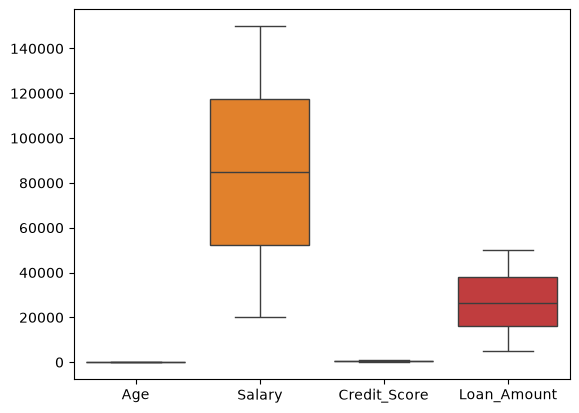

In [138]:
sns.boxplot(x[num_cols])

In [139]:
"""Preprocessing Technique

-scaling
-encoding

why scaling?
'Features(numerical) cols values are in different range(scale).So we can use scaling to equal importance for all the feature cols'

why encoding?
'Algorithms can only understand only number not strings'

which scaling and encoding techniques we can use for this?
Scaling - 1.'MinMaxScaler',2.'StandardScaler'

Encoding-
Loan_Term            4,Employment_Status    3,Residence_Type       3,Previous_Default     2
 
unique values are less so we can use OneHotEncoder"""

"Preprocessing Technique\n\n-scaling\n-encoding\n\nwhy scaling?\n'Features(numerical) cols values are in different range(scale).So we can use scaling to equal importance for all the feature cols'\n\nwhy encoding?\n'Algorithms can only understand only number not strings'\n\nwhich scaling and encoding techniques we can use for this?\nScaling - 1.'MinMaxScaler',2.'StandardScaler'\n\nEncoding-\nLoan_Term            4,Employment_Status    3,Residence_Type       3,Previous_Default     2\n\nunique values are less so we can use OneHotEncoder"

In [140]:
encoder =OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
scaling=MinMaxScaler()
model=LogisticRegression()


In [141]:
# xtrain 
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
#xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols])
encoded_values=encoder.fit_transform(xtrain[obj_cols])
encoded_columns=encoder.get_feature_names_out()

xtrain[encoded_columns]=encoded_values
xtrain.drop(columns=obj_cols,inplace=True)

In [142]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [143]:
# xtest 
xtest[num_cols]=scaling.transform(xtest[num_cols])
# xtest[obj_cols]=encoder.transform(xtest[obj_cols])
encoded_values=encoder.transform(xtest[obj_cols])
encoded_columns=encoder.get_feature_names_out()

xtest[encoded_columns]=encoded_values
xtest.drop(columns=obj_cols,inplace=True)

In [144]:
xtest

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,0.152174,0.220886,0.521898,0.540280,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,0.434783,0.687894,0.020073,0.453711,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,0.347826,0.836468,0.760949,0.652294,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,0.434783,0.315031,0.950730,0.116550,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,0.934783,0.605720,0.693431,0.587172,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,0.347826,0.976689,0.764599,0.938296,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,0.478261,0.012071,0.034672,0.038805,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,0.086957,0.540937,0.791971,0.830012,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [145]:
model.fit(xtrain,ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [146]:
y_test_pred = model.predict(xtest)
y_test_pred

array(['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'No',
       'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No',
       'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No',
       'Yes', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes',
       'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes',
       'Yes', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No',
       'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'No',
       'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No',
       'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
       'No', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Ye

In [147]:
y_train_pred = model.predict(xtrain)
y_train_pred

array(['Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No',
       'No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes',
       'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'Yes',
       'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes',
       'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No',
       'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes',
       'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes

# classification matrix

In [148]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(confusion_matrix(ytest, y_test_pred))
print(accuracy_score(ytest, y_test_pred))
print(precision_score(ytest, y_test_pred, pos_label="Yes"))
print(recall_score(ytest, y_test_pred, pos_label="Yes"))
print(f1_score(ytest, y_test_pred, pos_label="Yes"))

[[47 48]
 [53 52]]
0.495
0.52
0.49523809523809526
0.5073170731707317
